<a href="https://colab.research.google.com/github/Buddhiimz/DeepLearning_Project/blob/feature%2Fjithma/IT22095176_DL_Assigment_EfficientNetB0_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# imports and settings
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
tf.random.set_seed(123)
np.random.seed(123)

In [ ]:
# Mount Google Drive to access datasets
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Extract train zip folders
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Assignment/train.zip', 'r') as zip_ref:
    zip_ref.extractall('train')

In [ ]:
# Extract test zip folders
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Assignment/test.zip', 'r') as zip_ref:
    zip_ref.extractall('test')

In [ ]:
# Step 2: mapping from folder name (n0000 etc) to human orchid names
folder_map = {
    "n0000": "anoectochilus burmanicus rolfe.",
    "n0001": "bulbophyllum auricomum lindl.",
    "n0002": "bulbophyllum dayanum rchb",
    "n0003": "bulbophyllum lasiochilum par. & rchb",
    "n0004": "bulbophyllum limbatum",
    "n0005": "bulbophyllum longissimum (ridl.) ridl",
    "n0006": "bulbophyllum medusae (lindl.) rchb",
    "n0007": "bulbophyllum patens king ex hk.f.",
    "n0008": "bulbophyllum rufuslabram",
    "n0009": "bulbophyllum siamensis rchb",
    "n0010": "calenthe rubens",
    "n0011": "chiloschista parishii seidenf.",
    "n0012": "chiloschista viridiflora seidenf.",
    "n0013": "cymbidium aloifolium (l.) sw.",
    "n0014": "dendrobium chrysotoxum lindl",
    "n0015": "dendrobium farmeri paxt.",
    "n0016": "dendrobium fimbriatum hook",
    "n0017": "dendrobium lindleyi steud",
    "n0018": "dendrobium pulchellum roxb",
    "n0019": "dendrobium pulchellum",
    "n0020": "dendrobium secundum bl-lindl",
    "n0021": "dendrobium senile par. & rchb.f.",
    "n0022": "dendrobium signatum rchb. f",
    "n0023": "dendrobium thyrsiflorum rchb. f.",
    "n0024": "dendrobium tortile lindl",
    "n0025": "dendrobium tortile",
    "n0026": "hygrochillus parishii var. marrioftiana (rchb.f.)",
    "n0027": "paphiopedilum bellatulum",
    "n0028": "paphiopedilum callosum",
    "n0029": "paphiopedilum charlesworthii",
    "n0030": "paphiopedilum concolor",
    "n0031": "paphiopedilum exul",
    "n0032": "paphiopedilum godefroyae",
    "n0033": "paphiopedilum gratrixianum",
    "n0034": "paphiopedilum henryanum",
    "n0035": "paphiopedilum intanon-villosum",
    "n0036": "paphiopedilum niveum (rchb.f.) stein",
    "n0037": "paphiopedilum parishii",
    "n0038": "paphiopedilum spicerianum",
    "n0039": "paphiopedilum sukhakulii",
    "n0040": "pelatantheria bicuspidata (rolfe ex downie) tang & wang",
    "n0041": "pelatantheria insectiflora (rchb.f.) ridl.",
    "n0042": "phaius tankervilleae (banks ex i' heritier) blume",
    "n0043": "phalaenopsis cornucervi (breda) bl. & rchb.f.",
    "n0044": "rhynchostylis gigantea (lindl.) ridl.",
    "n0045": "trichoglottis orchideae (koern) garay.",
    "n0046": "bulbophyllum auratum lindl.",
    "n0047": "bulbophyllum morphologorum f.kranzl.",
    "n0048": "dendrobium cumulatum lindl.",
    "n0049": "maxiralia tenui folia",
    "n0050": "paphiopedilum vejvarutianum o. gruss & roellke",
    "n0051": "oncidium goldiana"
}


In [ ]:
# Cell 2: check folder structure and classes
TRAIN_DIR = '/content/train/train'
TEST_DIR  = '/content/test/test'

def list_class_folders(path):
    classes = [d for d in sorted(os.listdir(path)) if os.path.isdir(os.path.join(path, d))]
    return classes

train_classes = list_class_folders(TRAIN_DIR)
test_classes  = list_class_folders(TEST_DIR)

print("Detected train classes (count={}):".format(len(train_classes)), train_classes)
print("Detected test classes (count={}):".format(len(test_classes)), test_classes)

# show per-class counts (train)
def class_counts(path, classes):
    counts = {}
    for c in classes:
        p = os.path.join(path, c)
        files = [f for f in glob.glob(os.path.join(p, '*')) if os.path.isfile(f)]
        counts[c] = len(files)
    return counts

if train_classes:
    print("Train image counts by class:", class_counts(TRAIN_DIR, train_classes))
else:
    print("No class subfolders detected in", TRAIN_DIR, "- check your extraction.")


Detected train classes (count=52): ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n0051']
Detected test classes (count=52): ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n

In [ ]:
# Step 2: Dataset parameters
IMG_SIZE = 224   # EfficientNetB0 typically uses 224; can try 240 later
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Step 3: Load train & validation datasets from the same folder with split
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=123
)


Found 2820 files belonging to 52 classes.
Using 2256 files for training.
Found 2820 files belonging to 52 classes.
Using 564 files for validation.


In [ ]:
# Step 4: Test dataset (shuffle=False to align predictions)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 739 files belonging to 52 classes.


In [ ]:
# Step 5: Replace numeric folder names with human-readable names
class_names = [folder_map[name] for name in train_ds.class_names]
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)


Classes: ['anoectochilus burmanicus rolfe.', 'bulbophyllum auricomum lindl.', 'bulbophyllum dayanum rchb', 'bulbophyllum lasiochilum par. & rchb', 'bulbophyllum limbatum', 'bulbophyllum longissimum (ridl.) ridl', 'bulbophyllum medusae (lindl.) rchb', 'bulbophyllum patens king ex hk.f.', 'bulbophyllum rufuslabram', 'bulbophyllum siamensis rchb', 'calenthe rubens', 'chiloschista parishii seidenf.', 'chiloschista viridiflora seidenf.', 'cymbidium aloifolium (l.) sw.', 'dendrobium chrysotoxum lindl', 'dendrobium farmeri paxt.', 'dendrobium fimbriatum hook', 'dendrobium lindleyi steud', 'dendrobium pulchellum roxb', 'dendrobium pulchellum', 'dendrobium secundum bl-lindl', 'dendrobium senile par. & rchb.f.', 'dendrobium signatum rchb. f', 'dendrobium thyrsiflorum rchb. f.', 'dendrobium tortile lindl', 'dendrobium tortile', 'hygrochillus parishii var. marrioftiana (rchb.f.)', 'paphiopedilum bellatulum', 'paphiopedilum callosum', 'paphiopedilum charlesworthii', 'paphiopedilum concolor', 'paphi

In [ ]:
# Step 6: Performance tuning
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [ ]:
from tensorflow.keras import layers
import os, glob

# Step 1: Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    # Optional: add RandomContrast, RandomTranslation etc.
], name='data_augmentation')

# Step 2: Compute class weights
# Use original folder IDs for counting files
folder_ids = list(folder_map.keys())  # ['n0000', 'n0001', ...]
counts = [len(glob.glob(os.path.join(TRAIN_DIR, f_id, '*'))) for f_id in folder_ids]
total = sum(counts)
class_weights = {i: total / (NUM_CLASSES * counts[i]) for i in range(NUM_CLASSES)}

print("Per-class counts:", dict(zip(class_names, counts)))  # human-readable labels
print("Class weights:", class_weights)


Per-class counts: {'anoectochilus burmanicus rolfe.': 48, 'bulbophyllum auricomum lindl.': 48, 'bulbophyllum dayanum rchb': 22, 'bulbophyllum lasiochilum par. & rchb': 49, 'bulbophyllum limbatum': 18, 'bulbophyllum longissimum (ridl.) ridl': 29, 'bulbophyllum medusae (lindl.) rchb': 23, 'bulbophyllum patens king ex hk.f.': 16, 'bulbophyllum rufuslabram': 25, 'bulbophyllum siamensis rchb': 43, 'calenthe rubens': 19, 'chiloschista parishii seidenf.': 88, 'chiloschista viridiflora seidenf.': 49, 'cymbidium aloifolium (l.) sw.': 70, 'dendrobium chrysotoxum lindl': 50, 'dendrobium farmeri paxt.': 43, 'dendrobium fimbriatum hook': 66, 'dendrobium lindleyi steud': 144, 'dendrobium pulchellum roxb': 104, 'dendrobium pulchellum': 51, 'dendrobium secundum bl-lindl': 92, 'dendrobium senile par. & rchb.f.': 28, 'dendrobium signatum rchb. f': 26, 'dendrobium thyrsiflorum rchb. f.': 22, 'dendrobium tortile lindl': 165, 'dendrobium tortile': 19, 'hygrochillus parishii var. marrioftiana (rchb.f.)': 31

In [ ]:
# Input + augmentation
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)                  # on-the-fly augmentation
x = layers.Lambda(preprocess_input, name='preproc')(x)  # EfficientNet preprocessing

# Base model (feature extractor)
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze for stage 1
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dropout(0.3)(x)   # consider 0.4-0.5 if overfitting
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
model = models.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  # ok for integer labels
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preproc (Lambda)                │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 52)             │        66,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,116,183 (15.70 MB)

 Trainable params: 66,612 (260.20 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
CHECKPOINT_PATH = '/content/best_effnetb0.weights.h5'

# Callbacks
cb_checkpoint = callbacks.ModelCheckpoint(
    CHECKPOINT_PATH, monitor='val_accuracy',
    save_best_only=True, save_weights_only=True, verbose=1
)
cb_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
)
cb_early = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1
)

# Training head only
EPOCHS_HEAD = 30
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[cb_checkpoint, cb_reduce, cb_early],
    class_weight=class_weights
)


Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0224 - loss: 3.9566
Epoch 1: val_accuracy improved from -inf to 0.07979, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.0226 - loss: 3.9562 - val_accuracy: 0.0798 - val_loss: 3.7718 - learning_rate: 1.0000e-04
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1061 - loss: 3.6200
Epoch 2: val_accuracy improved from 0.07979 to 0.23404, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.1064 - loss: 3.6192 - val_accuracy: 0.2340 - val_loss: 3.4407 - learning_rate: 1.0000e-04
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2431 - loss: 3.2898
Epoch 3: val_accuracy improved from 0.23404 to 0.36170, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 317s 4s/step - accuracy: 0.2436 - loss: 3.2895 - val_accuracy: 0.3617 - val_loss: 3.1410 - learning_rate: 1.0000e-04
Epoc

In [ ]:
# Unfreeze top layers of base model
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.75)  # unfreeze top 25%
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning
EPOCHS_FINE = 20
initial_epoch = len(history_head.history['loss'])
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch + EPOCHS_FINE,
    initial_epoch=initial_epoch,
    callbacks=[cb_checkpoint, cb_reduce, cb_early],
    class_weight=class_weights
)


Epoch 31/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7288 - loss: 1.6370
Epoch 31: val_accuracy did not improve from 0.87766
71/71 ━━━━━━━━━━━━━━━━━━━━ 345s 5s/step - accuracy: 0.7288 - loss: 1.6363 - val_accuracy: 0.8582 - val_loss: 0.7396 - learning_rate: 1.0000e-05
Epoch 32/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7413 - loss: 1.4745
Epoch 32: val_accuracy did not improve from 0.87766
71/71 ━━━━━━━━━━━━━━━━━━━━ 358s 5s/step - accuracy: 0.7415 - loss: 1.4736 - val_accuracy: 0.8422 - val_loss: 0.8448 - learning_rate: 1.0000e-05
Epoch 33/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8048 - loss: 1.2643
Epoch 33: val_accuracy did not improve from 0.87766
71/71 ━━━━━━━━━━━━━━━━━━━━ 305s 4s/step - accuracy: 0.8048 - loss: 1.2644 - val_accuracy: 0.8404 - val_loss: 0.8964 - learning_rate: 1.0000e-05
Epoch 34/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8156 - loss: 1.1720
Epoch 34: val_accuracy did not improve from 0.87766

Epoch 34: ReduceLROnPla

In [ ]:
# Save the trained model in HDF5 format
model.save('/content/drive/MyDrive/Colab Notebooks/Assignment/orchid_classifier.keras')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Load best weights
model.load_weights(CHECKPOINT_PATH)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 114 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Evaluate overall loss & accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}\n")

24/24 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.7717 - loss: 1.1069
Test loss: 1.0232  Test accuracy: 0.7835



In [ ]:
business_value_map = {
    "anoectochilus burmanicus rolfe.": ("High", "$50 – $150"),
    "bulbophyllum auricomum lindl.": ("Medium", "$20 – $50"),
    "bulbophyllum dayanum rchb": ("Medium", "$20 – $50"),
    "bulbophyllum lasiochilum par. & rchb": ("Medium", "$25 – $60"),
    "bulbophyllum limbatum": ("Medium", "$20 – $45"),
    "bulbophyllum longissimum (ridl.) ridl": ("High", "$60 – $120"),
    "bulbophyllum medusae (lindl.) rchb": ("High", "$70 – $130"),
    "bulbophyllum patens king ex hk.f.": ("Medium", "$25 – $55"),
    "bulbophyllum rufuslabram": ("Medium", "$20 – $40"),
    "bulbophyllum siamensis rchb": ("Medium", "$20 – $45"),
    "calenthe rubens": ("Low", "$10 – $25"),
    "chiloschista parishii seidenf.": ("Medium", "$20 – $50"),
    "chiloschista viridiflora seidenf.": ("Medium", "$25 – $55"),
    "cymbidium aloifolium (l.) sw.": ("High", "$60 – $120"),
    "dendrobium chrysotoxum lindl": ("Medium", "$25 – $60"),
    "dendrobium farmeri paxt.": ("Medium", "$20 – $50"),
    "dendrobium fimbriatum hook": ("Medium", "$20 – $45"),
    "dendrobium lindleyi steud": ("Medium", "$20 – $45"),
    "dendrobium pulchellum roxb": ("Medium", "$25 – $55"),
    "dendrobium pulchellum": ("Medium", "$25 – $55"),
    "dendrobium secundum bl-lindl": ("Low", "$10 – $25"),
    "dendrobium senile par. & rchb.f.": ("High", "$50 – $100"),
    "dendrobium signatum rchb. f": ("Medium", "$25 – $60"),
    "dendrobium thyrsiflorum rchb. f.": ("High", "$50 – $100"),
    "dendrobium tortile lindl": ("Medium", "$25 – $50"),
    "dendrobium tortile": ("Medium", "$25 – $50"),
    "hygrochillus parishii var. marrioftiana (rchb.f.)": ("High", "$60 – $120"),
    "paphiopedilum bellatulum": ("High", "$80 – $150"),
    "paphiopedilum callosum": ("High", "$70 – $140"),
    "paphiopedilum charlesworthii": ("High", "$80 – $150"),
    "paphiopedilum concolor": ("High", "$70 – $140"),
    "paphiopedilum exul": ("Medium", "$30 – $70"),
    "paphiopedilum godefroyae": ("High", "$80 – $160"),
    "paphiopedilum gratrixianum": ("High", "$70 – $140"),
    "paphiopedilum henryanum": ("High", "$90 – $160"),
    "paphiopedilum intanon-villosum": ("High", "$80 – $150"),
    "paphiopedilum niveum (rchb.f.) stein": ("High", "$90 – $160"),
    "paphiopedilum parishii": ("High", "$80 – $150"),
    "paphiopedilum spicerianum": ("High", "$80 – $150"),
    "paphiopedilum sukhakulii": ("High", "$70 – $130"),
    "pelatantheria bicuspidata (rolfe ex downie) tang & wang": ("Medium", "$25 – $55"),
    "pelatantheria insectiflora (rchb.f.) ridl.": ("Medium", "$25 – $55"),
    "phaius tankervilleae (banks ex i' heritier) blume": ("Medium", "$30 – $60"),
    "phalaenopsis cornucervi (breda) bl. & rchb.f.": ("High", "$70 – $130"),
    "rhynchostylis gigantea (lindl.) ridl.": ("High", "$80 – $150"),
    "trichoglottis orchideae (koern) garay.": ("Medium", "$25 – $50"),
    "bulbophyllum auratum lindl.": ("Medium", "$25 – $55"),
    "bulbophyllum morphologorum f.kranzl.": ("Medium", "$25 – $55"),
    "dendrobium cumulatum lindl.": ("Medium", "$25 – $55"),
    "maxiralia tenui folia": ("Low", "$10 – $25"),
    "paphiopedilum vejvarutianum o. gruss & roellke": ("High", "$90 – $160"),
    "oncidium goldiana": ("Medium", "$25 – $55"),
}


In [ ]:
# Cell 10: Prediction function
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_orchid(image_path):
    # Load and preprocess image
    img = image.load_img(image_path, target_size=(224, 224))  # resize as per your model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)
    pred_class = np.argmax(prediction)
    pred_class_name = class_names[pred_class]

    # Get business value
    business_value, price_range = business_value_map.get(pred_class_name, ("Unknown", "N/A"))

In [ ]:
# Predictions and true labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step


In [ ]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Classification Report:

                                                         precision    recall  f1-score   support

                        anoectochilus burmanicus rolfe.     0.9286    1.0000    0.9630        13
                          bulbophyllum auricomum lindl.     0.8462    0.8462    0.8462        13
                              bulbophyllum dayanum rchb     0.8571    1.0000    0.9231         6
                   bulbophyllum lasiochilum par. & rchb     0.8333    0.7692    0.8000        13
                                  bulbophyllum limbatum     0.6667    0.4000    0.5000         5
                  bulbophyllum longissimum (ridl.) ridl     0.8571    0.7500    0.8000         8
                     bulbophyllum medusae (lindl.) rchb     1.0000    1.0000    1.0000         6
                      bulbophyllum patens king ex hk.f.     1.0000    0.4000    0.5714         5
                               bulbophyllum rufuslabram     0.3333    0.1250    0.1818         8
     

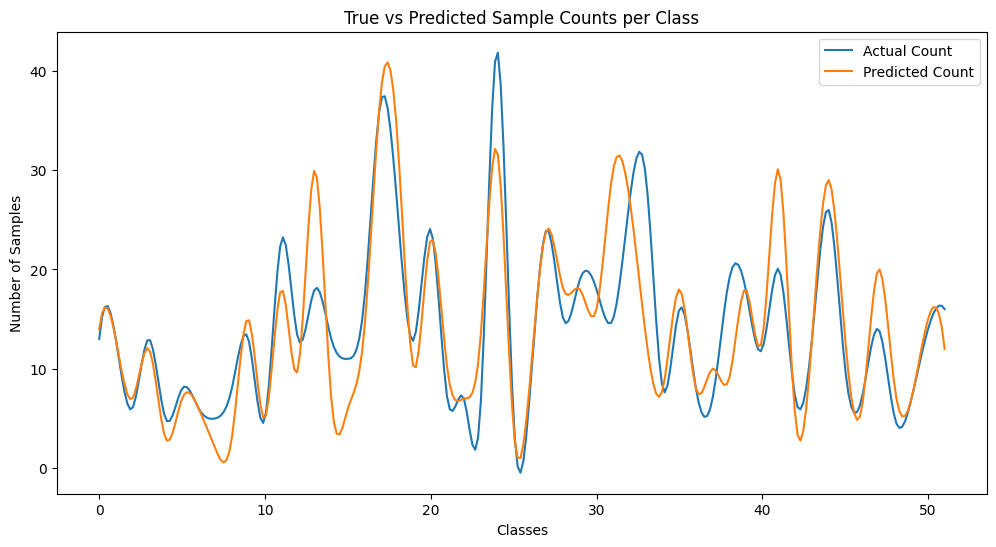

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Sum of true and predicted samples per class
true_counts = np.sum(cm, axis=1)   # total true instances per class
pred_counts = np.sum(cm, axis=0)   # total predicted instances per class

# Plot line graph
plt.figure(figsize=(12,6))
plt.plot(x_smooth, true_smooth, label='Actual Count')
plt.plot(x_smooth, pred_smooth, label='Predicted Count')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.title('True vs Predicted Sample Counts per Class')
plt.legend()
plt.show()

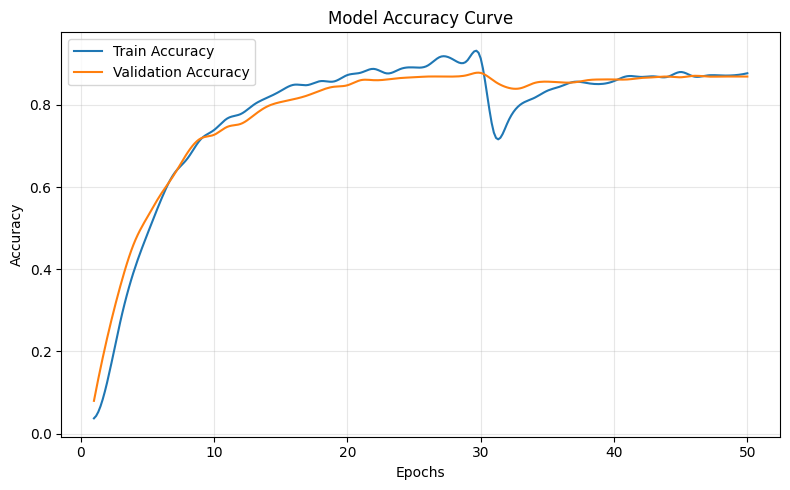

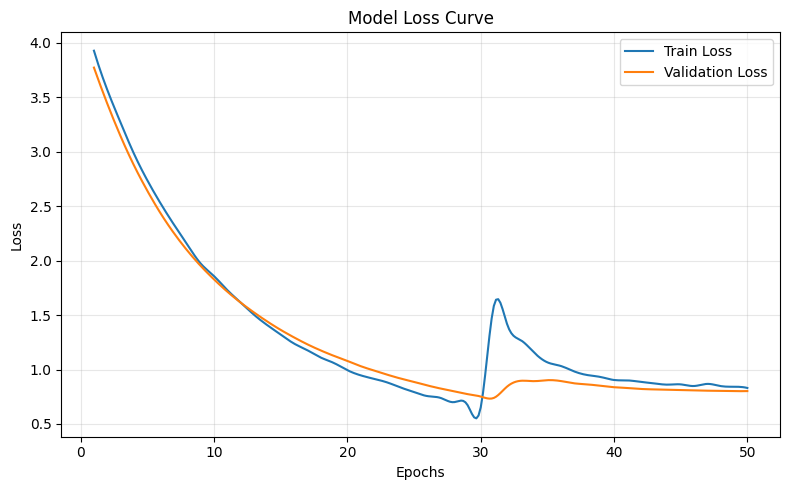

In [ ]:
# Combine both histories if you did fine-tuning
acc = history_head.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_head.history['loss'] + history_fine.history['loss']
val_loss = history_head.history['val_loss'] + history_fine.history['val_loss']

epochs_range = np.arange(1, len(acc) + 1)

# smooth accuracy curves
x_smooth = np.linspace(epochs_range.min(), epochs_range.max(), 300)
spl_acc = make_interp_spline(epochs_range, acc, k=3)
acc_smooth = spl_acc(x_smooth)
spl_val_acc = make_interp_spline(epochs_range, val_acc, k=3)
val_acc_smooth = spl_val_acc(x_smooth)

# Accuracy curve
plt.figure(figsize=(8,5))
plt.plot(x_smooth, acc_smooth, label='Train Accuracy')
plt.plot(x_smooth, val_acc_smooth, label='Validation Accuracy')
plt.title('Model Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# smooth loss curves
spl_loss = make_interp_spline(epochs_range, loss, k=3)
loss_smooth = spl_loss(x_smooth)
spl_val_loss = make_interp_spline(epochs_range, val_loss, k=3)
val_loss_smooth = spl_val_loss(x_smooth)

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(x_smooth, loss_smooth, label='Train Loss')
plt.plot(x_smooth, val_loss_smooth, label='Validation Loss')
plt.title('Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Final Training Accuracy
final_train_acc = history_fine.history['accuracy'][-1] * 100
final_val_acc = history_fine.history['val_accuracy'][-1] * 100

print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")

Final Training Accuracy: 87.68%
Final Validation Accuracy: 86.88%


In [ ]:
# Save the trained model in HDF5 format
model.save('/content/drive/MyDrive/Colab Notebooks/Assignment/orchid_classifier.keras')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Give your test image path
img_path = "/content/test/test/n0002/orchid-0001-สิงโตขยุกขยุย_25.JPEG"

# Load and preprocess the image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape (1, IMG_SIZE, IMG_SIZE, 3)
img_array = preprocess_input(img_array)

# Predict using your trained model
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]

# Show result
print("Predicted class index:", pred_class)
print("Predicted label:", class_names[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted class index: 2
Predicted label: bulbophyllum dayanum rchb


In [ ]:
# Give your test image path
img_path = "/content/test/test/n0020/orchid-0013-แปรงสีฟัน_88.JPEG"

# Load and preprocess the image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape (1, IMG_SIZE, IMG_SIZE, 3)
img_array = preprocess_input(img_array)

# Predict using your trained model
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]

# Show result
print("Predicted class index:", pred_class)
print("Predicted label:", class_names[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Predicted class index: 20
Predicted label: dendrobium secundum bl-lindl


In [ ]:
# Test image path
img_path = "/content/test/test/n0002/orchid-0001-สิงโตขยุกขยุย_25.JPEG"

# Load and preprocess
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
pred_class_name = class_names[pred_class]

# Show basic prediction
print(f"Predicted class index: {pred_class}")
print(f"Predicted Orchid: {pred_class_name}")

# Lookup business value and price
business_info = business_value_map.get(pred_class_name, ("Unknown", "Unknown"))
business_value, price_range = business_info

# Print the extra details
print(f"Business Value: {business_value}")
print(f"Estimated Price Range: {price_range}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Predicted class index: 2
Predicted Orchid: bulbophyllum dayanum rchb
Business Value: Medium
Estimated Price Range: $20 – $50


In [ ]:
# Test image path
img_path = "/content/test/test/n0020/orchid-0013-แปรงสีฟัน_88.JPEG"

# Load and preprocess
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
pred_class_name = class_names[pred_class]

# Show basic prediction
print(f"Predicted class index: {pred_class}")
print(f"Predicted Orchid: {pred_class_name}")

# Lookup business value and price
business_info = business_value_map.get(pred_class_name, ("Unknown", "Unknown"))
business_value, price_range = business_info

# Print the extra details
print(f"Business Value: {business_value}")
print(f"Estimated Price Range: {price_range}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted class index: 20
Predicted Orchid: dendrobium secundum bl-lindl
Business Value: Low
Estimated Price Range: $10 – $25


In [ ]:
# Test image path
img_path = "/content/train/train/n0000/orchid-0006-นกคุ้มไฟ_30.JPEG"

# Load and preprocess
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
pred_class_name = class_names[pred_class]

# Show basic prediction
print(f"Predicted class index: {pred_class}")
print(f"Predicted Orchid: {pred_class_name}")

# Lookup business value and price
business_info = business_value_map.get(pred_class_name, ("Unknown", "Unknown"))
business_value, price_range = business_info

# Print the extra details
print(f"Business Value: {business_value}")
print(f"Estimated Price Range: {price_range}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Predicted class index: 0
Predicted Orchid: anoectochilus burmanicus rolfe.
Business Value: High
Estimated Price Range: $50 – $150


In [ ]:
# Test image path
img_path = "/content/drive/MyDrive/Colab Notebooks/Assignment/Maxillaria_tenuifolia.jpg"

# Load and preprocess
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
pred_class_name = class_names[pred_class]

# Show basic prediction
print(f"Predicted class index: {pred_class}")
print(f"Predicted Orchid: {pred_class_name}")

# Lookup business value and price
business_info = business_value_map.get(pred_class_name, ("Unknown", "Unknown"))
business_value, price_range = business_info

# Print the extra details
print(f"Business Value: {business_value}")
print(f"Estimated Price Range: {price_range}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
Predicted class index: 49
Predicted Orchid: maxiralia tenui folia
Business Value: Low
Estimated Price Range: $10 – $25


In [ ]:
# Test image path
img_path = "/content/drive/MyDrive/Colab Notebooks/Assignment/henryanum.jpeg"

# Load and preprocess
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
pred_class_name = class_names[pred_class]

# Show basic prediction
print(f"Predicted class index: {pred_class}")
print(f"Predicted Orchid: {pred_class_name}")

# Lookup business value and price
business_info = business_value_map.get(pred_class_name, ("Unknown", "Unknown"))
business_value, price_range = business_info

# Print the extra details
print(f"Business Value: {business_value}")
print(f"Estimated Price Range: {price_range}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Predicted class index: 34
Predicted Orchid: paphiopedilum henryanum
Business Value: High
Estimated Price Range: $90 – $160
